In [146]:
import numpy as np
import matplotlib.pyplot as plt
import math

Metropolis-Hastings for a PMF (n-sided die)

In [147]:
def t(x): #target density function, let's assume that its bounded from 0 to 1 for simplicity. i am ignoring the normalization factor
    return 1/(1+x**2) 

def t_CDF(x):
    return math.atan(x) #again this is off by a factor, but we don't care

In [148]:
PI = np.array([0.1*(1/4), 0.1*(1/2), 0.1*(1/12), 0.9, 0.1*(1/18), 0.1*(1/9)])

# PI = []
# num_buckets = 100
# T = 2
# x_coords = np.linspace(-T, T, num_buckets+1)

# for i in range(num_buckets):
#     PI.append(t_CDF(x_coords[i+1]) - t_CDF(x_coords[i]))

#remember PI is not normalized


def proposal_strat_unbiased(i,j):
    if 0 <= i and i <= len(PI) - 1 and 0 <= j and j <= len(PI) - 1:
        return 1/len(PI)
    return 15

def proposal_strat_sticky(i,j):
    if 0 <= i and i <= len(PI) - 1 and 0 <= j and j <= len(PI) - 1:
        if i != 3:
            return 1/len(PI)
        if i == 3 and j != 3:
            return 0.01*(1/(len(PI)-1))
        if i == 3 and j == 3:
            return 0.999
    return 15

def g(i,j): #our proposal probabilities
    return proposal_strat_unbiased(i,j)


def A(i,j):
    if 0 <= i and i <= len(PI) - 1 and 0 <= j and j <= len(PI) - 1:
        return min(1, (PI[j]/PI[i])*(g(j,i)/(g(i,j))))
    return 15

def P(i,j):
    if 0 <= i and i <= len(PI) - 1 and 0 <= j and j <= len(PI) - 1:
        return g(i,j)*A(i,j)
    return 15

In [149]:
samples_with_burn_in = [1]
N = 1000

for i in range(N):
    unif = np.random.random()
    proposal_state = 0

    proposal = [g(samples_with_burn_in[-1], j) for j in range(len(PI))]
    proposal_CDF = [sum(proposal[0:i+1]) for i in range(len(PI))]

    for j in proposal_CDF:
        if j < unif:
            proposal_state += 1
    
        

    if np.random.random() < A(samples_with_burn_in[-1], proposal_state):
        samples_with_burn_in.append(proposal_state)
    else:
        samples_with_burn_in.append(samples_with_burn_in[-1])


In [150]:
samples = samples_with_burn_in[1000:]

frequency_counter = dict({})
total_frequency = len(samples)

for i in samples:
    try:
        val = frequency_counter[i]
    except:
        val = 0
    frequency_counter.update({i: val+1})


X = []
p_X = []
for key, value in frequency_counter.items():
    X.append(key)
    p_X.append(value/total_frequency)


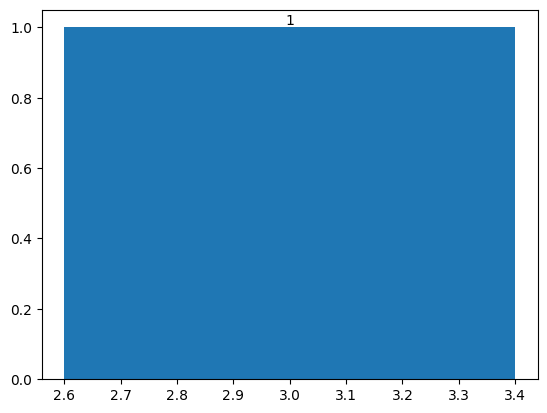

0.025
0.05
0.008333333333333333
0.9
0.005555555555555556
0.011111111111111112


In [151]:
fig, ax = plt.subplots()
bars = ax.bar(X, p_X)

ax.bar_label(bars)

plt.show()

# # density histogram (area = 1)
# ax.hist(X, bins=len(X), weights=p_X, density=True,
#         alpha=0.5, label="approx density")

# # true PDF
# y_coords = [(1/2*math.atan(T))*t(x) for x in x_coords]
# ax.plot(x_coords, y_coords, color='red', label="true PDF")

# ax.legend()
# plt.show()



for i in PI:
    print(i)



In [152]:
#Transition matrix of our markov chain
transition_matrix = np.zeros((len(PI), len(PI)))
for i in range(len(PI)):
    for j in range(len(PI)):
        if i != j:
            transition_matrix[i,j] = P(i,j)

for i in range(len(PI)):
    transition_matrix[i,i] = 1 - sum(transition_matrix[i])


In [153]:
print(np.array(PI) @ transition_matrix)  #transition_matrix has PI as its stationary distribution!
print(np.array(PI))

[0.025      0.05       0.00833333 0.9        0.00555556 0.01111111]
[0.025      0.05       0.00833333 0.9        0.00555556 0.01111111]
